In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing  import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import numpy as np
import pandas as pd
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier 
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [6]:
#Import Data from CSV
Data_df = pd.read_csv('diabetes_012_health_indicators_BRFSS2015.csv')
Data2_df = Data_df
Data_df.head()
Data_df.columns


Index(['Diabetes_012', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker',
       'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
       'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
       'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education',
       'Income'],
      dtype='object')

In [4]:
Data_df.head()

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0,1,1,1,40,1,0,0,0,0,...,1,0,5,18,15,1,0,9,4,3
1,0,0,0,0,25,1,0,0,1,0,...,0,1,3,0,0,0,0,7,6,1
2,0,1,1,1,28,0,0,0,0,1,...,1,1,5,30,30,1,0,9,4,8
3,0,1,0,1,27,0,0,0,1,1,...,1,0,2,0,0,0,0,11,3,6
4,0,1,1,1,24,0,0,0,1,1,...,1,0,2,3,0,0,0,11,5,4


## Diabetes Section Analysis

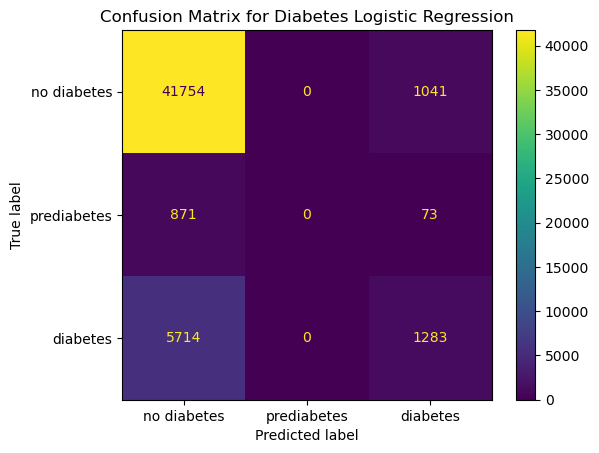

 the accuracy is 0.8482537054556922


In [3]:
'''Diabetes Analysis Logisitc Regression'''
Y_diabetes = Data_df['Diabetes_012']
X_diabetes = Data2_df.drop(columns=['Diabetes_012']) #0 = no diabetes 1 = prediabetes 2 = diabetes

# Split the dataset into training and testing sets
X_diab_train, X_diab_test, y_diab_train, y_diab_test = train_test_split(X_diabetes, Y_diabetes, test_size=0.2, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_diab_train_scaled = scaler.fit_transform(X_diab_train)
X_diab_test_scaled = scaler.transform(X_diab_test)

# Train a logistic regression model
model_Log = LogisticRegression()
model_Log.fit(X_diab_train_scaled, y_diab_train)

# Make predictions
Y_diab_pred_log = model_Log.predict(X_diab_test_scaled)


# Display the confusion matrix
cfm = confusion_matrix(y_diab_test, Y_diab_pred_log)
ConfusionMatrixDisplay(cfm, display_labels = ['no diabetes', 'prediabetes', 'diabetes']).plot()
plt.title('Confusion Matrix for Diabetes Logistic Regression')
plt.show()

#calculate accuracy
from sklearn.metrics import accuracy_score
accuracy_score(y_diab_test, Y_diab_pred_log)

print(f' the accuracy is {accuracy_score(y_diab_test, Y_diab_pred_log)}')



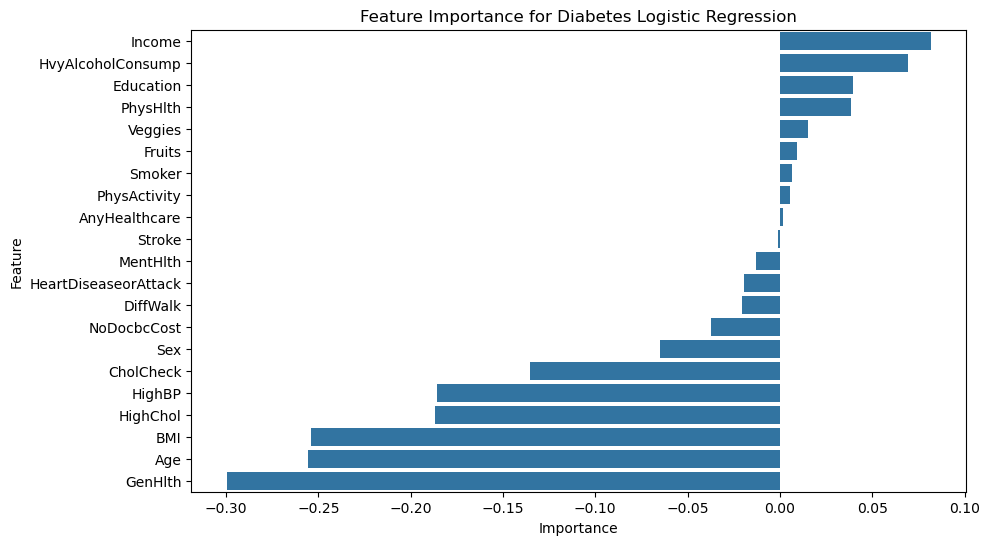

In [4]:
#which features are important
importance = model_Log.coef_[0]
feature_names = X_diab_train.columns
# Create a DataFrame to hold feature names and their importance
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importance})
# Sort the DataFrame by importance
importance_df = importance_df.sort_values(by='Importance', ascending=False)
# Plot the feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Feature Importance for Diabetes Logistic Regression')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

In [5]:
# Diabetes Analysis Decision Tree
from sklearn.tree import DecisionTreeClassifier, plot_tree

tree_diab= DecisionTreeClassifier(max_depth = 4)    # max_depth = 4
tree_diab.fit(X_diab_train_scaled, y_diab_train)  # fit the model

y_diab_pred_tree = tree_diab.predict(X_diab_test_scaled) 

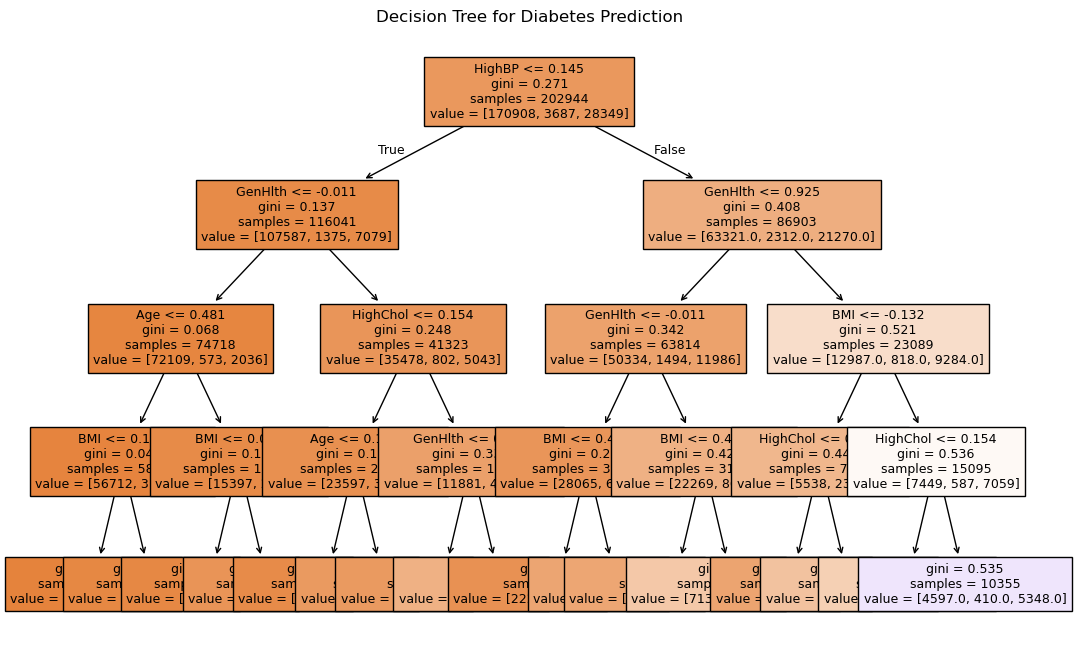

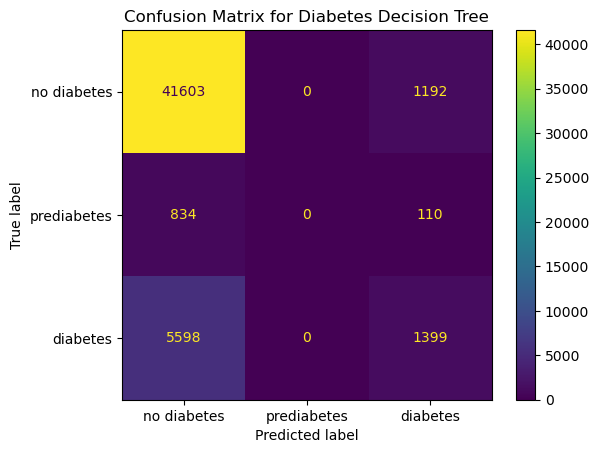

 the accuracy is 0.8475638599810785


In [6]:
#plot the decision tree 
plt.figure(figsize=(12,8))
plot_tree(tree_diab, fontsize = 9, feature_names=X_diab_train.columns, filled=True)
plt.title('Decision Tree for Diabetes Prediction')
plt.show()

# Display the confusion matrix
cfm = confusion_matrix(y_diab_test, y_diab_pred_tree)
ConfusionMatrixDisplay(cfm, display_labels = ['no diabetes', 'prediabetes', 'diabetes']).plot()
plt.title('Confusion Matrix for Diabetes Decision Tree')
plt.show()
#calculate accuracy
from sklearn.metrics import accuracy_score
accuracy_score(y_diab_test, y_diab_pred_tree)
print(f' the accuracy is {accuracy_score(y_diab_test, y_diab_pred_tree)}')



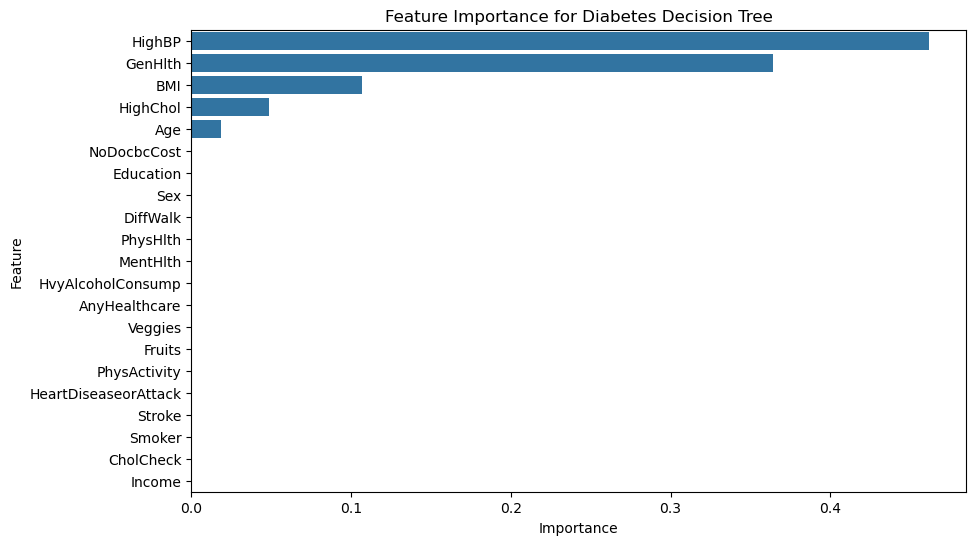

In [7]:
#which features are important
importance = tree_diab.feature_importances_
feature_names = X_diab_train.columns
# Create a DataFrame to hold feature names and their importance
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importance})
# Sort the DataFrame by importance
importance_df = importance_df.sort_values(by='Importance', ascending=False)
# Plot the feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Feature Importance for Diabetes Decision Tree')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

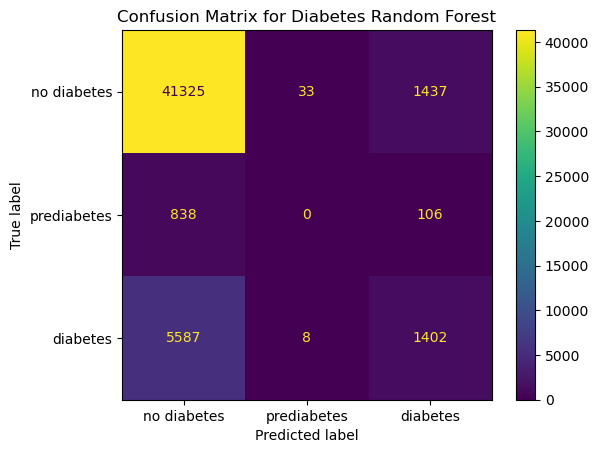

 the accuracy is 0.8421436455376853


In [8]:
#Diabetes Analysis Random Forest

rf_diab = RandomForestClassifier()
rf_diab.fit(X_diab_train_scaled, y_diab_train)

y_diab_pred = rf_diab.predict(X_diab_test_scaled)

from sklearn.metrics import accuracy_score

# Display the confusion matrix
cfm = confusion_matrix(y_diab_test, y_diab_pred)
ConfusionMatrixDisplay(cfm, display_labels = ['no diabetes', 'prediabetes', 'diabetes']).plot()
#ConfusionMatrixDisplay(cfm).plot()
plt.title('Confusion Matrix for Diabetes Random Forest')
plt.show()

print(f' the accuracy is {accuracy_score(y_diab_test, y_diab_pred)}')


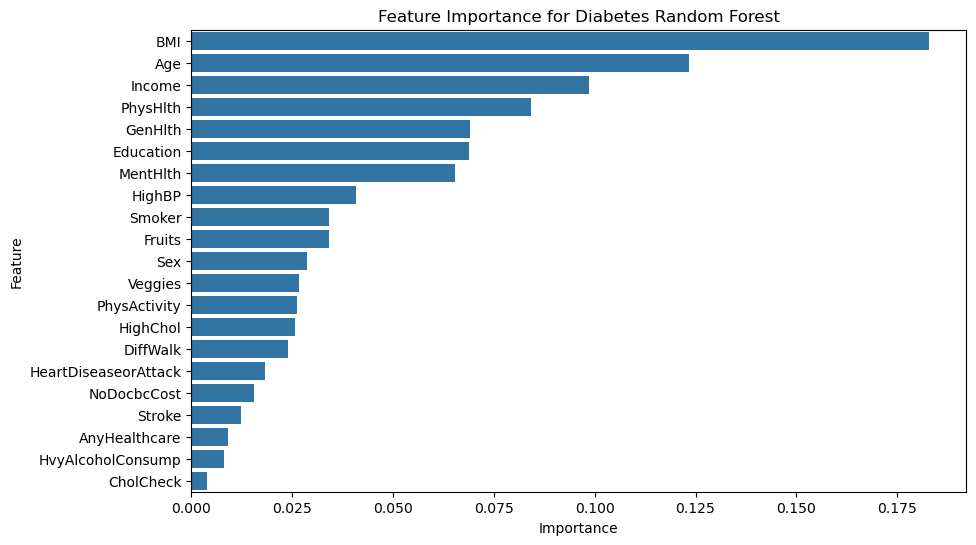

In [9]:
#which features are important
importance = rf_diab.feature_importances_
feature_names = X_diab_train.columns
# Create a DataFrame to hold feature names and their importance
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importance})
# Sort the DataFrame by importance
importance_df = importance_df.sort_values(by='Importance', ascending=False)
# Plot the feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Feature Importance for Diabetes Random Forest')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

## Stroke Section Analysis

In [10]:
'''Stroke Analysis Logistic Regression'''
Y_stroke = Data_df['Stroke']
X_stroke = Data2_df.drop(columns=['Stroke']) #0 = no stroke 1 = stroke



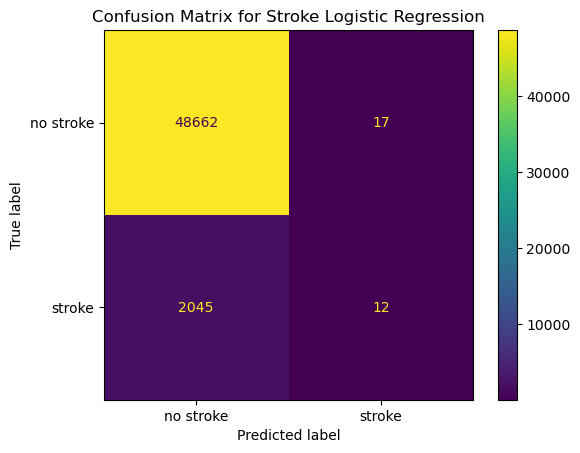

 the accuracy is 0.9593582466099022


In [11]:
'''Logistic Regression'''
# Split the dataset into training and testing sets
X_stroke_train, X_stroke_test, y_stroke_train, y_stroke_test = train_test_split(X_stroke, Y_stroke, test_size=0.2, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_stroke_train_scaled = scaler.fit_transform(X_stroke_train)
X_stroke_test_scaled = scaler.transform(X_stroke_test)

# Train a logistic regression model
model_Log = LogisticRegression()
model_Log.fit(X_stroke_train_scaled, y_stroke_train)

# Make predictions
Y_stroke_pred_log = model_Log.predict(X_stroke_test_scaled)

# Display the confusion matrix
cfm = confusion_matrix(y_stroke_test, Y_stroke_pred_log)
ConfusionMatrixDisplay(cfm, display_labels = ['no stroke', 'stroke']).plot()
plt.title('Confusion Matrix for Stroke Logistic Regression')
plt.show()


#calculate accuracy
from sklearn.metrics import accuracy_score
accuracy_score(y_stroke_test, Y_stroke_pred_log)
print(f' the accuracy is {accuracy_score(y_stroke_test, Y_stroke_pred_log)}')


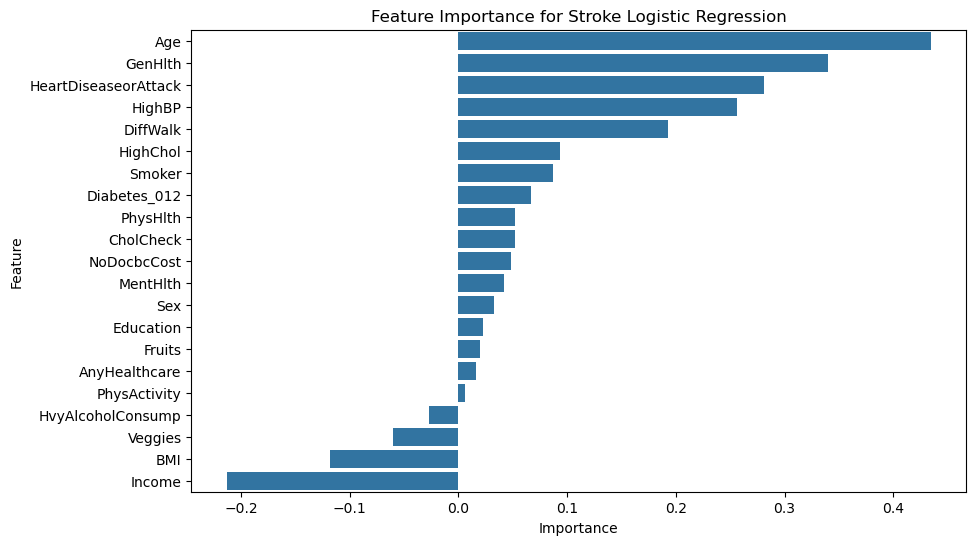

In [12]:
#which features are important
importance = model_Log.coef_[0]
feature_names = X_stroke_train.columns
# Create a DataFrame to hold feature names and their importance
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importance})
# Sort the DataFrame by importance
importance_df = importance_df.sort_values(by='Importance', ascending=False)
# Plot the feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Feature Importance for Stroke Logistic Regression')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

In [27]:
'''Stroke Decision Tree '''
# Diabetes Analysis Decision Tree
from sklearn.tree import DecisionTreeClassifier, plot_tree

tree_stroke= DecisionTreeClassifier(max_depth = 20, class_weight='balanced')    # max_depth = 4
tree_stroke.fit(X_stroke_train_scaled, y_stroke_train)  # fit the model

y_stroke_pred_tree = tree_diab.predict(X_stroke_test_scaled) 

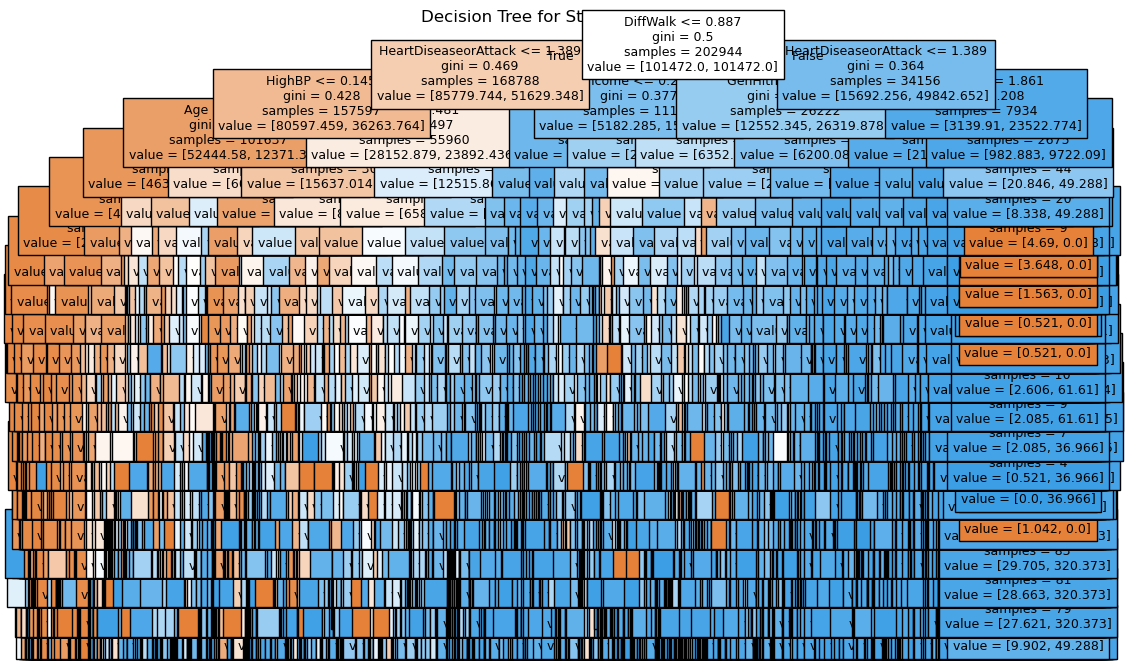

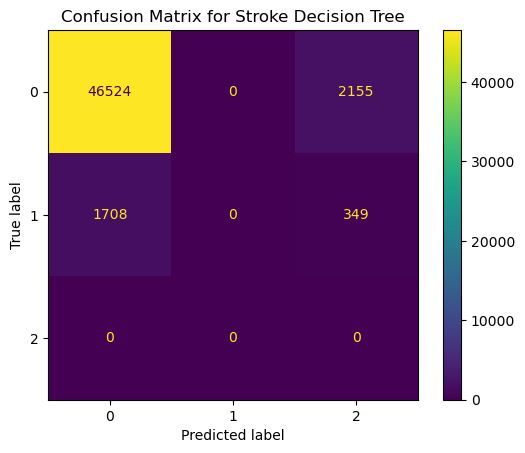

 the accuracy is 0.9169820245979187


In [28]:
#plot the decision tree 
plt.figure(figsize=(12,8))
plot_tree(tree_stroke, fontsize = 9, feature_names=X_stroke_train.columns, filled=True)
plt.title('Decision Tree for Stroke Prediction')
plt.show()

#confusion matrix
cfm = confusion_matrix(y_stroke_test, y_stroke_pred_tree)
ConfusionMatrixDisplay(cfm).plot()
plt.title('Confusion Matrix for Stroke Decision Tree')
plt.show()
#calculate accuracy
from sklearn.metrics import accuracy_score
print(f' the accuracy is {accuracy_score(y_stroke_test, y_stroke_pred_tree)}')

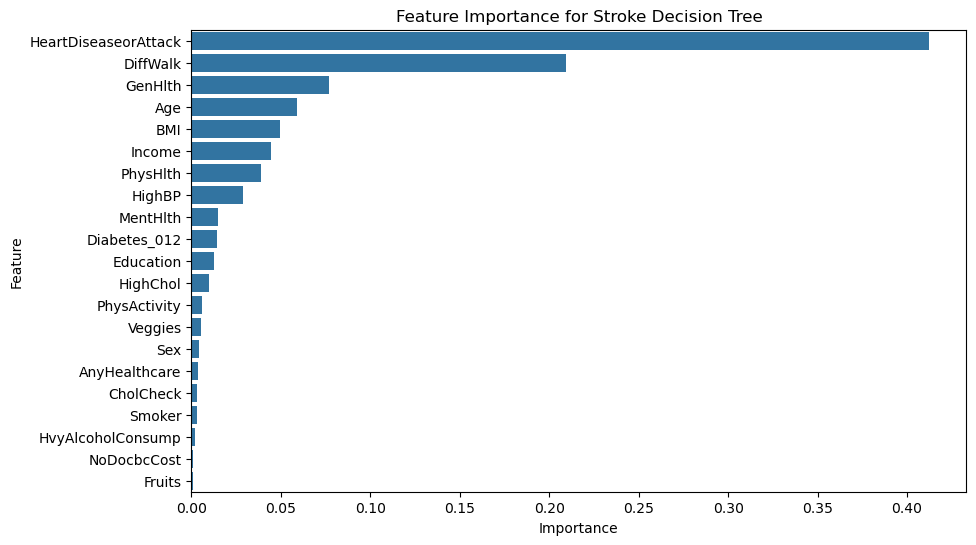

In [15]:

#which features are important
importance = tree_stroke.feature_importances_
feature_names = X_stroke_train.columns
# Create a DataFrame to hold feature names and their importance
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importance})
# Sort the DataFrame by importance
importance_df = importance_df.sort_values(by='Importance', ascending=False)
# Plot the feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Feature Importance for Stroke Decision Tree')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

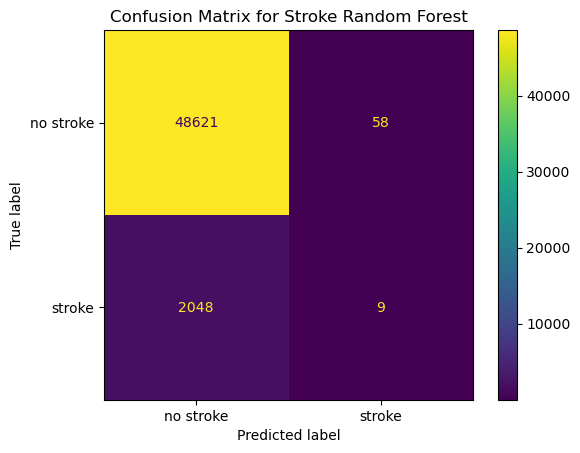

 the accuracy is 0.8421436455376853


In [16]:
'''Stroke Random Forest'''

rf_stroke = RandomForestClassifier()
rf_stroke.fit(X_stroke_train_scaled, y_stroke_train)
y_stroke_pred_rf = rf_stroke.predict(X_stroke_test_scaled)

from sklearn.metrics import accuracy_score

# Display the confusion matrix
cfm = confusion_matrix(y_stroke_test, y_stroke_pred_rf)
ConfusionMatrixDisplay(cfm, display_labels = ['no stroke', 'stroke']).plot()
plt.title('Confusion Matrix for Stroke Random Forest')
#ConfusionMatrixDisplay(cfm).plot()
plt.show()

print(f' the accuracy is {accuracy_score(y_diab_test, y_diab_pred)}')


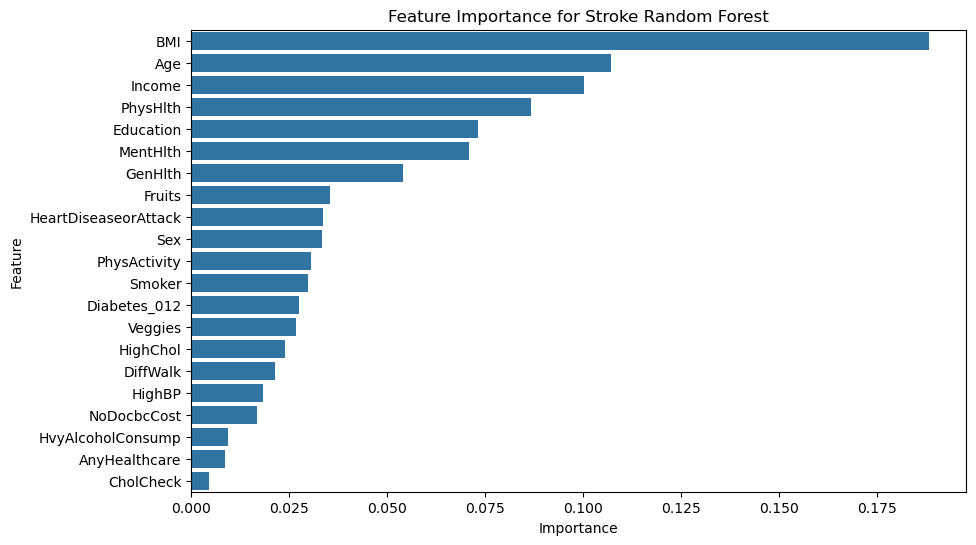

In [17]:
#which features are important
importance = rf_stroke.feature_importances_
feature_names = X_stroke_train.columns
# Create a DataFrame to hold feature names and their importance
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importance})
# Sort the DataFrame by importance
importance_df = importance_df.sort_values(by='Importance', ascending=False)
# Plot the feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Feature Importance for Stroke Random Forest')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

## Heart Disease Analysis

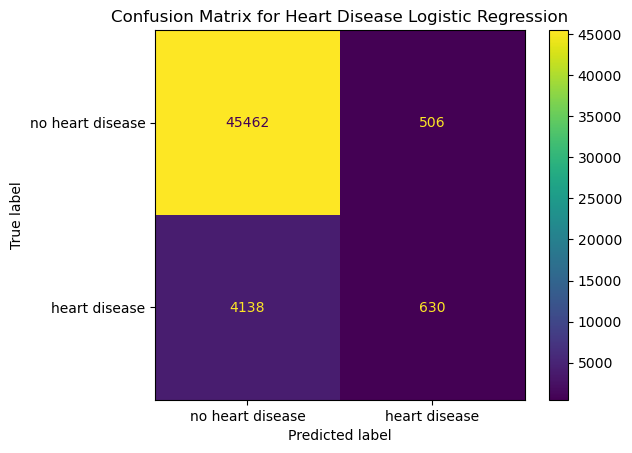

 the accuracy is 0.9084673604541155


In [18]:
Y_Heart = Data_df['HeartDiseaseorAttack']
X_Heart = Data2_df.drop(columns=['HeartDiseaseorAttack'])

'''Heart Disease Analysis Logistic Regression'''
# Split the dataset into training and testing sets
X_heart_train, X_heart_test, y_heart_train, y_heart_test = train_test_split(X_Heart, Y_Heart, test_size=0.2, random_state=42)

#standardize the features
scaler = StandardScaler()
X_heart_train_scaled = scaler.fit_transform(X_heart_train)
X_heart_test_scaled = scaler.transform(X_heart_test)

# Train a logistic regression model
model_Log = LogisticRegression()
model_Log.fit(X_heart_train_scaled, y_heart_train)
# Make predictions
Y_heart_pred_log = model_Log.predict(X_heart_test_scaled)


# Display the confusion matrix
cfm = confusion_matrix(y_heart_test, Y_heart_pred_log)
ConfusionMatrixDisplay(cfm, display_labels = ['no heart disease', 'heart disease']).plot()
plt.title('Confusion Matrix for Heart Disease Logistic Regression')
plt.show()
#calculate accuracy
from sklearn.metrics import accuracy_score
accuracy_score(y_heart_test, Y_heart_pred_log)
print(f' the accuracy is {accuracy_score(y_heart_test, Y_heart_pred_log)}')


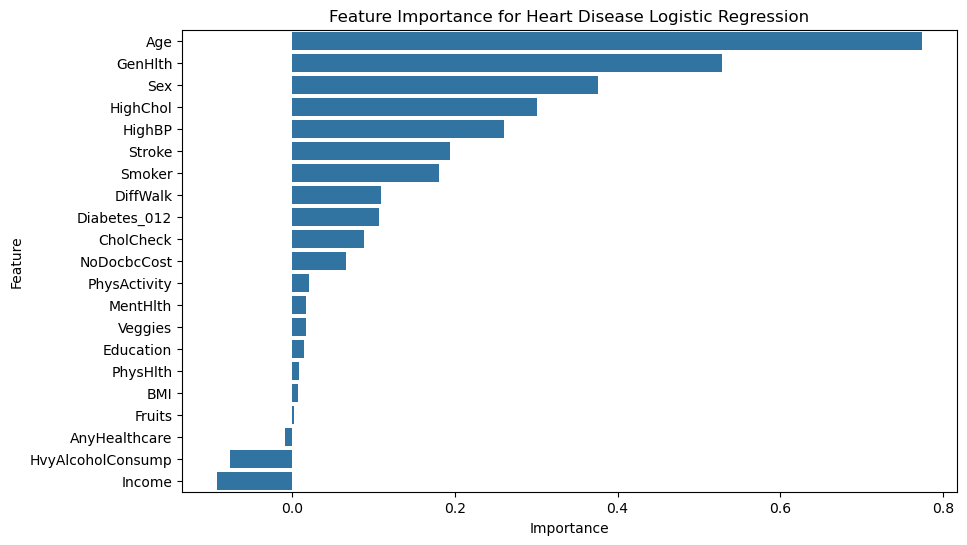

In [19]:

#which features are important
importance = model_Log.coef_[0]
feature_names = X_heart_train.columns
# Create a DataFrame to hold feature names and their importance
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importance})
# Sort the DataFrame by importance
importance_df = importance_df.sort_values(by='Importance', ascending=False)
# Plot the feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Feature Importance for Heart Disease Logistic Regression')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

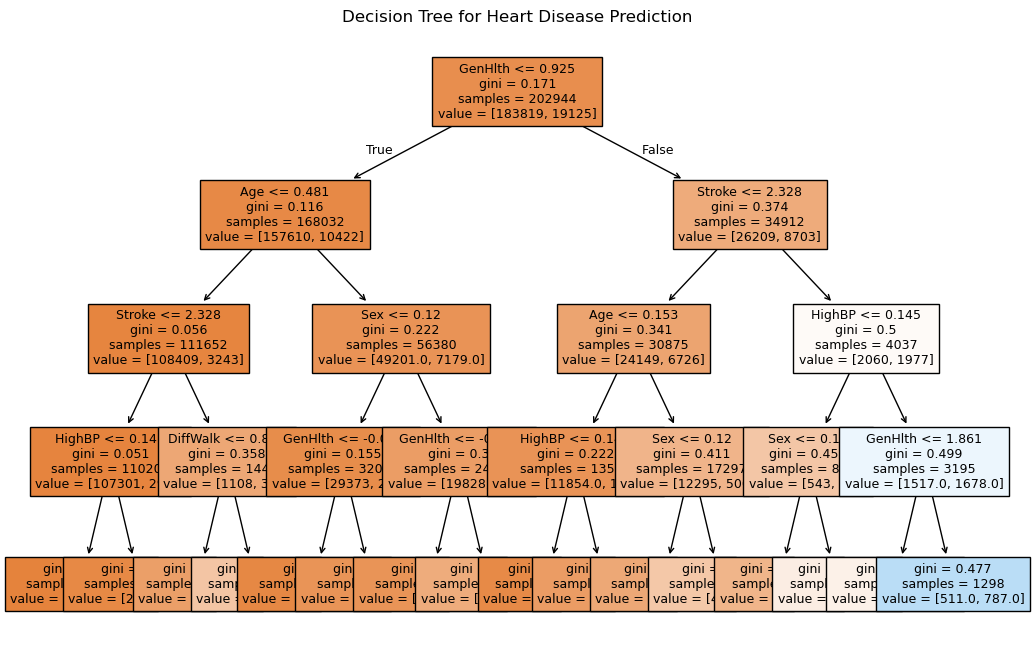

In [20]:
#Heart Disease Analysis Decision Tree
from sklearn.tree import DecisionTreeClassifier, plot_tree
tree_heart= DecisionTreeClassifier(max_depth = 4)    # max_depth = 4
tree_heart.fit(X_heart_train_scaled, y_heart_train)  # fit the model

y_heart_pred_tree = tree_heart.predict(X_heart_test_scaled)

#plot the decision tree
plt.figure(figsize=(12,8))
plot_tree(tree_heart, fontsize = 9, feature_names=X_heart_train.columns, filled=True)
plt.title('Decision Tree for Heart Disease Prediction')
plt.show()

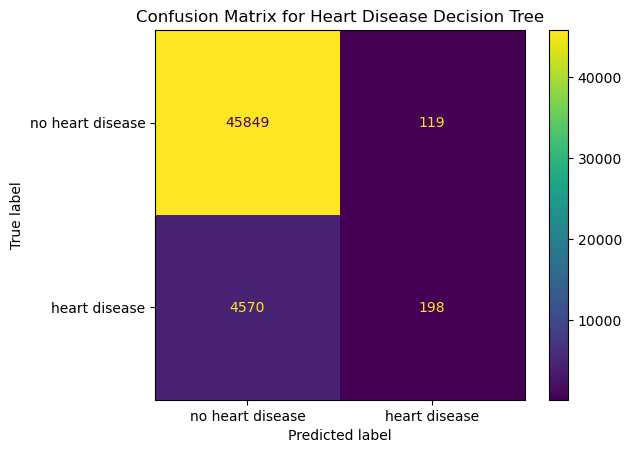

 the accuracy is 0.9075804162724692


In [21]:

#accuracy score
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score
# Display the confusion matrix

cfm = confusion_matrix(y_heart_test, y_heart_pred_tree)
ConfusionMatrixDisplay(cfm, display_labels = ['no heart disease', 'heart disease']).plot()
plt.title('Confusion Matrix for Heart Disease Decision Tree')
plt.show()
print(f' the accuracy is {accuracy_score(y_heart_test, y_heart_pred_tree)}')

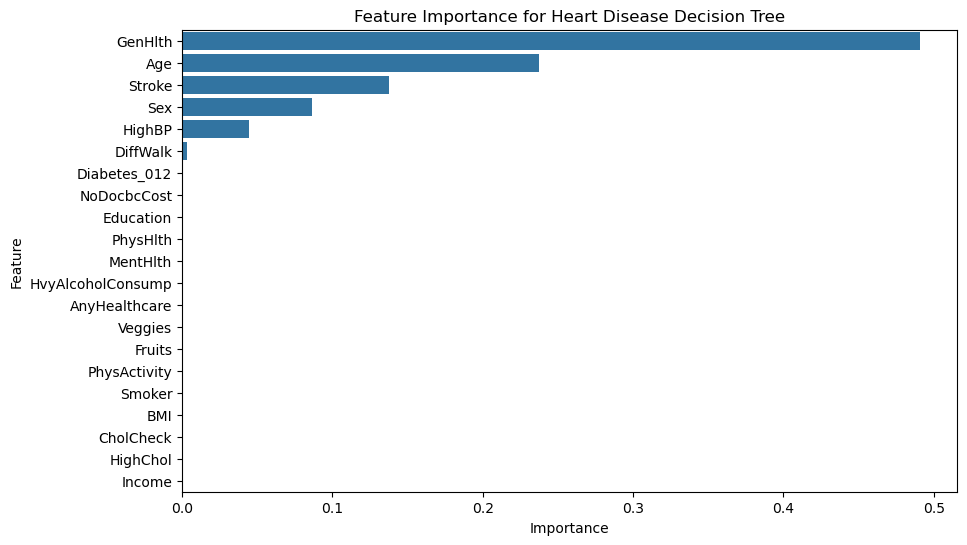

In [22]:
#which features are important
importance = tree_heart.feature_importances_
feature_names = X_heart_train.columns
# Create a DataFrame to hold feature names and their importance
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importance})
# Sort the DataFrame by importance
importance_df = importance_df.sort_values(by='Importance', ascending=False)
# Plot the feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Feature Importance for Heart Disease Decision Tree')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

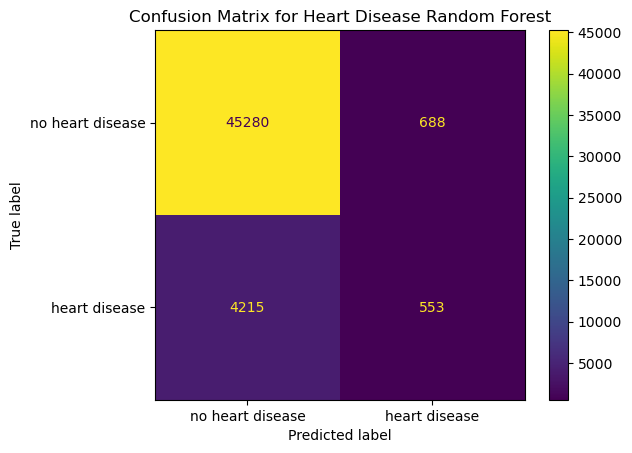

 the accuracy is 0.9033625039419741


In [23]:
'''Heart Disease Random Forest'''
rf_heart = RandomForestClassifier()
rf_heart.fit(X_heart_train_scaled, y_heart_train)
y_heart_pred = rf_heart.predict(X_heart_test_scaled)
from sklearn.metrics import accuracy_score
# Display the confusion matrix
cfm = confusion_matrix(y_heart_test, y_heart_pred)
ConfusionMatrixDisplay(cfm, display_labels = ['no heart disease', 'heart disease']).plot()
plt.title('Confusion Matrix for Heart Disease Random Forest')
plt.show()

print(f' the accuracy is {accuracy_score(y_heart_test, y_heart_pred)}')

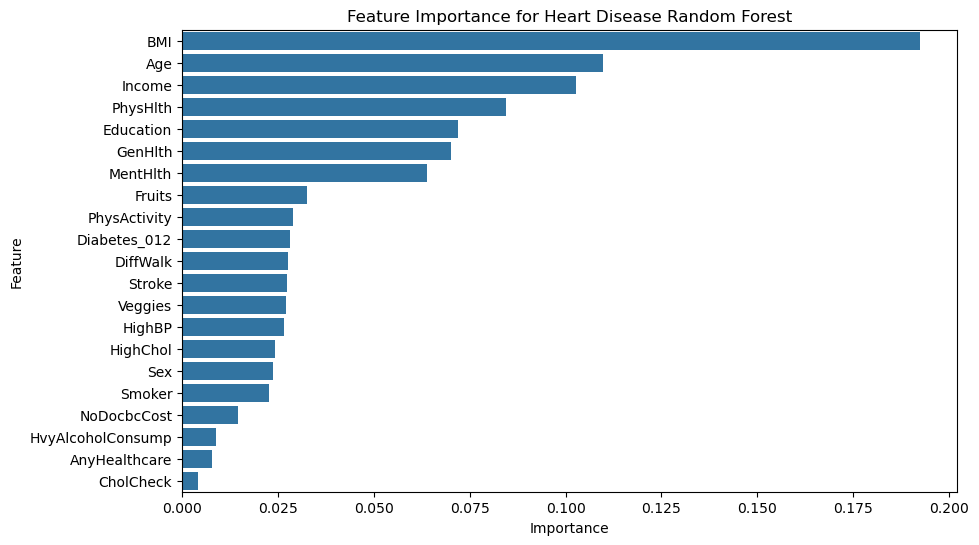

In [24]:
#which features are important
importance = rf_heart.feature_importances_
feature_names = X_heart_train.columns
# Create a DataFrame to hold feature names and their importance
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importance})
# Sort the DataFrame by importance
importance_df = importance_df.sort_values(by='Importance', ascending=False)
# Plot the feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Feature Importance for Heart Disease Random Forest')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()